<a href="https://colab.research.google.com/github/achasinavas/TP1_Programacion_UBA/blob/main/versi%C3%B3n_2_tp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maestría en Economía Aplicada - Universidad de Buenos Aires

Grupo 2:
*   Andrea Chasi
*   Pablo Ortiz
*   Santiago Soler


# Carga de paquetes y configuración inicial

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Crear carpeta para guardar tablas y figuras
os.makedirs("salidas", exist_ok=True)

print("Paquetes cargados correctamente.")

Paquetes cargados correctamente.


## 1. Carga de datos

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

ruta = "/content/drive/MyDrive/tp1_taller_de_programacion/"

eph24 = pd.read_excel(ruta + "usu_individual_T424.xlsx")
eph25 = pd.read_excel(ruta + "usu_individual_T425.xlsx")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#2. Selección de variables

In [8]:

# Variables de identificación de personas/hogares
variables_id = [
    "CODUSU",
    "ANO4",
    "TRIMESTRE",
    "NRO_HOGAR",
    "COMPONENTE",
    "PONDERA"
]

# Variables obligatorias según la consigna
variables_obligatorias = [
    "CH04",        # Sexo
    "CH06",        # Edad
    "CH07",        # Estado civil
    "CH08",        # Cobertura de salud
    "NIVEL_ED",    # Nivel educativo
    "ESTADO",      # Condición de actividad
    "CAT_OCUP",    # Categoría ocupacional
    "EMPLEO",      # Empleo
    "SECTOR",      # Sector
    "PP04C",       # Tamaño del establecimiento
    "PP04D_COD",   # Código de ocupación
    "P21",         # Ingreso ocupación principal
    "P47T"         # Ingreso total individual
]

# Variables adicionales útiles para informalidad y análisis descriptivo
variables_adicionales = [
    "AGLOMERADO",
    "REGION",
    "PP07H",       # Descuento jubilatorio
    "PP07I",
    "PP07J",
    "PP07K",
    "PP08D1",
    "PP08F1"
]

# Lista final
variables = variables_id + variables_obligatorias + variables_adicionales

print("Cantidad de variables seleccionadas:", len(variables))
print(variables)

Cantidad de variables seleccionadas: 27
['CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'COMPONENTE', 'PONDERA', 'CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_OCUP', 'EMPLEO', 'SECTOR', 'PP04C', 'PP04D_COD', 'P21', 'P47T', 'AGLOMERADO', 'REGION', 'PP07H', 'PP07I', 'PP07J', 'PP07K', 'PP08D1', 'PP08F1']


#3. Verificación de variables existentes

In [9]:
faltantes_2024 = [v for v in variables if v not in eph24.columns]
faltantes_2025 = [v for v in variables if v not in eph25.columns]

print("Variables faltantes en 2024:", faltantes_2024)
print("Variables faltantes en 2025:", faltantes_2025)

if len(faltantes_2024) == 0 and len(faltantes_2025) == 0:
    print("Todas las variables seleccionadas están presentes en ambas bases.")
else:
    print("Revisar las variables faltantes antes de continuar.")

Variables faltantes en 2024: []
Variables faltantes en 2025: []
Todas las variables seleccionadas están presentes en ambas bases.


# 4. Subconjuntos de variables tipo años 2024 y 2025

In [10]:

eph24_sel = eph24[variables].copy()
eph25_sel = eph25[variables].copy()

# Comparación inicial de tipos
comparacion_tipos_inicial = pd.DataFrame({
    "variable": variables,
    "tipo_2024": [eph24_sel[v].dtype for v in variables],
    "tipo_2025": [eph25_sel[v].dtype for v in variables]
})

comparacion_tipos_inicial["mismo_tipo"] = (
    comparacion_tipos_inicial["tipo_2024"] == comparacion_tipos_inicial["tipo_2025"]
)

comparacion_tipos_inicial

,variable,tipo_2024,tipo_2025,mismo_tipo
0,CODUSU,object,object,True
1,ANO4,int64,int64,True
2,TRIMESTRE,int64,int64,True
3,NRO_HOGAR,int64,int64,True
4,COMPONENTE,int64,int64,True
5,PONDERA,int64,int64,True
6,CH04,int64,int64,True
7,CH06,int64,int64,True
8,CH07,int64,int64,True
9,CH08,int64,int64,True


#5. Conversión de variables numéricas

In [11]:
# CODUSU se mantiene como identificador de texto
variables_numericas = [v for v in variables if v != "CODUSU"]

for var in variables_numericas:
    eph24_sel[var] = pd.to_numeric(eph24_sel[var], errors="coerce")
    eph25_sel[var] = pd.to_numeric(eph25_sel[var], errors="coerce")

# Comparación posterior de tipos
comparacion_tipos_final = pd.DataFrame({
    "variable": variables,
    "tipo_2024": [eph24_sel[v].dtype for v in variables],
    "tipo_2025": [eph25_sel[v].dtype for v in variables]
})

comparacion_tipos_final["mismo_tipo"] = (
    comparacion_tipos_final["tipo_2024"] == comparacion_tipos_final["tipo_2025"]
)

comparacion_tipos_final

,variable,tipo_2024,tipo_2025,mismo_tipo
0,CODUSU,object,object,True
1,ANO4,int64,int64,True
2,TRIMESTRE,int64,int64,True
3,NRO_HOGAR,int64,int64,True
4,COMPONENTE,int64,int64,True
5,PONDERA,int64,int64,True
6,CH04,int64,int64,True
7,CH06,int64,int64,True
8,CH07,int64,int64,True
9,CH08,int64,int64,True


#6. Limpieza de valores atípicos

In [12]:
# Reemplazar ingresos negativos por NaN
# En EPH, valores negativos suelen corresponder a no respuesta, no sabe/no contesta
for df in [eph24_sel, eph25_sel]:
    for var in ["P21", "P47T"]:
        df.loc[df[var] < 0, var] = np.nan

# Agregar año
eph24_sel["anio"] = 2024
eph25_sel["anio"] = 2025

# Unir bases
base = pd.concat([eph24_sel, eph25_sel], ignore_index=True)

print("Base final unificada:", base.shape)
print(base["anio"].value_counts())

Base final unificada: (90563, 28)
anio
2024    46860
2025    43703
Name: count, dtype: int64


#7. Creación de variables: respondieron, norespondieron y ocupados

In [13]:
respondieron = base[base["ESTADO"] != 0].copy()
norespondieron = base[base["ESTADO"] == 0].copy()
ocupados = respondieron[respondieron["ESTADO"] == 1].copy()

print("Cantidad de personas que NO respondieron ESTADO por año:")
display(norespondieron.groupby("anio").size().reset_index(name="no_respondieron"))

print("Cantidad de personas que SÍ respondieron ESTADO por año:")
display(respondieron.groupby("anio").size().reset_index(name="respondieron"))

print("Cantidad de personas ocupadas por año:")
display(ocupados.groupby("anio").size().reset_index(name="ocupados"))

Cantidad de personas que NO respondieron ESTADO por año:


,anio,no_respondieron
0,2024,56
1,2025,65


Cantidad de personas que SÍ respondieron ESTADO por año:


,anio,respondieron
0,2024,46804
1,2025,43638


Cantidad de personas ocupadas por año:


,anio,ocupados
0,2024,21132
1,2025,19698


#8. Variables binarias

In [14]:
ocupados["mujer"] = (ocupados["CH04"] == 2).astype(int)
ocupados["hombre"] = (ocupados["CH04"] == 1).astype(int)
ocupados["casado_unido"] = ocupados["CH07"].isin([1, 2]).astype(int)
ocupados["universitario"] = (ocupados["NIVEL_ED"] >= 6).astype(int)
ocupados["asalariado"] = (ocupados["CAT_OCUP"] == 3).astype(int)

# Variable de cobertura de salud: tiene algún tipo de cobertura distinta a no tener
ocupados["tiene_cobertura_salud"] = (~ocupados["CH08"].isin([4, 9])).astype(int)

# Variable de descuento jubilatorio
# PP07H == 1: tiene descuento jubilatorio
# PP07H == 2: no tiene descuento jubilatorio
ocupados["con_descuento_jubilatorio"] = (ocupados["PP07H"] == 1).astype(int)
ocupados["sin_descuento_jubilatorio"] = (ocupados["PP07H"] == 2).astype(int)

ocupados[[
    "anio", "CH04", "mujer", "hombre", "CH07", "casado_unido",
    "NIVEL_ED", "universitario", "CAT_OCUP", "asalariado",
    "PP07H", "con_descuento_jubilatorio", "sin_descuento_jubilatorio"
]].head()

,anio,CH04,mujer,hombre,CH07,casado_unido,NIVEL_ED,universitario,CAT_OCUP,asalariado,PP07H,con_descuento_jubilatorio,sin_descuento_jubilatorio
3,2024,1,0,1,1,1,6,1,3,1,1.00,1,0
4,2024,2,1,0,1,1,6,1,3,1,1.00,1,0
5,2024,1,0,1,2,1,5,0,3,1,1.00,1,0
6,2024,2,1,0,2,1,6,1,3,1,1.00,1,0
10,2024,1,0,1,1,1,6,1,3,1,1.00,1,0


#9. Ajuste de ingresos 2024 a pesos de 2025

In [15]:

FACTOR_ACTUALIZACION_2024_A_2025 = 1.315

ocupados["P21_ajustado"] = np.where(
    ocupados["anio"] == 2024,
    ocupados["P21"] * FACTOR_ACTUALIZACION_2024_A_2025,
    ocupados["P21"]
)

ocupados["P47T_ajustado"] = np.where(
    ocupados["anio"] == 2024,
    ocupados["P47T"] * FACTOR_ACTUALIZACION_2024_A_2025,
    ocupados["P47T"]
)

respondieron["P21_ajustado"] = np.where(
    respondieron["anio"] == 2024,
    respondieron["P21"] * FACTOR_ACTUALIZACION_2024_A_2025,
    respondieron["P21"]
)

respondieron["P47T_ajustado"] = np.where(
    respondieron["anio"] == 2024,
    respondieron["P47T"] * FACTOR_ACTUALIZACION_2024_A_2025,
    respondieron["P47T"]
)

print("Factor de actualización aplicado:", FACTOR_ACTUALIZACION_2024_A_2025)

Factor de actualización aplicado: 1.315


#10. Indicador de informalidad

In [16]:
# Códigos tentativos de PP04C:
# 1 = 1 persona
# 2 = 2 personas
# 3 = 3 personas
# 4 = 4 personas
# 5 = 5 personas
# 6 o más = más de 5 personas
# Validar con el diccionario EPH.

ocupados["empresa_hasta_5"] = ocupados["PP04C"].isin([1, 2, 3, 4, 5]).astype(int)
ocupados["empresa_mas_5"] = ocupados["PP04C"].isin([6, 7, 8, 9, 10, 11, 12]).astype(int)

ocupados["formal_wage_employee"] = (
    (ocupados["CAT_OCUP"] == 3) &
    (ocupados["PP07H"] == 1)
).astype(int)

ocupados["upper_tier_informal_wage_employee"] = (
    (ocupados["CAT_OCUP"] == 3) &
    (ocupados["PP07H"] == 2) &
    (ocupados["empresa_mas_5"] == 1)
).astype(int)

ocupados["lower_tier_informal_wage_employee"] = (
    (ocupados["CAT_OCUP"] == 3) &
    (ocupados["PP07H"] == 2) &
    (ocupados["empresa_hasta_5"] == 1)
).astype(int)

def clasificar_condicion_laboral(row):
    if row["formal_wage_employee"] == 1:
        return "Formal wage employee"
    elif row["upper_tier_informal_wage_employee"] == 1:
        return "Upper-tier informal wage employee"
    elif row["lower_tier_informal_wage_employee"] == 1:
        return "Lower-tier informal wage employee"
    else:
        return "Resto de ocupados"

ocupados["condicion_laboral"] = ocupados.apply(clasificar_condicion_laboral, axis=1)

ocupados["condicion_laboral"].value_counts(dropna=False)

,count
condicion_laboral,
Formal wage employee,18542
Resto de ocupados,15517
Lower-tier informal wage employee,3816
Upper-tier informal wage employee,2955


#11. Tabla formal/informal por total, mujeres y hombres

In [17]:
def porcentaje_ponderado(sub, condicion):
    numerador = sub.loc[condicion, "PONDERA"].sum()
    denominador = sub["PONDERA"].sum()
    if denominador == 0:
        return np.nan
    return 100 * numerador / denominador

filas = []

for anio in [2024, 2025]:
    df_anio = ocupados[ocupados["anio"] == anio].copy()

    grupos = {
        "Total": df_anio,
        "Mujeres": df_anio[df_anio["CH04"] == 2],
        "Hombres": df_anio[df_anio["CH04"] == 1]
    }

    for nombre_grupo, sub in grupos.items():
        pct_formal = porcentaje_ponderado(
            sub,
            sub["formal_wage_employee"] == 1
        )

        pct_upper_informal = porcentaje_ponderado(
            sub,
            sub["upper_tier_informal_wage_employee"] == 1
        )

        pct_lower_informal = porcentaje_ponderado(
            sub,
            sub["lower_tier_informal_wage_employee"] == 1
        )

        pct_resto = 100 - pct_formal - pct_upper_informal - pct_lower_informal

        filas.append({
            "Año": anio,
            "Grupo": nombre_grupo,
            "Formal wage employee (%)": pct_formal,
            "Upper-tier informal wage employee (%)": pct_upper_informal,
            "Lower-tier informal wage employee (%)": pct_lower_informal,
            "Resto de ocupados (%)": pct_resto
        })

tabla_informalidad = pd.DataFrame(filas).round(2)

tabla_informalidad

,Año,Grupo,Formal wage employee (%),Upper-tier informal wage employee (%),Lower-tier informal wage employee (%),Resto de ocupados (%)
0,2024,Total,46.20,7.25,8.90,37.64
1,2024,Mujeres,46.43,7.48,6.54,39.55
2,2024,Hombres,46.01,7.07,10.81,36.11
3,2025,Total,45.55,6.68,8.87,38.90
4,2025,Mujeres,45.48,6.35,7.05,41.12
5,2025,Hombres,45.60,6.94,10.33,37.13


#12. Heatmap de valores faltantes

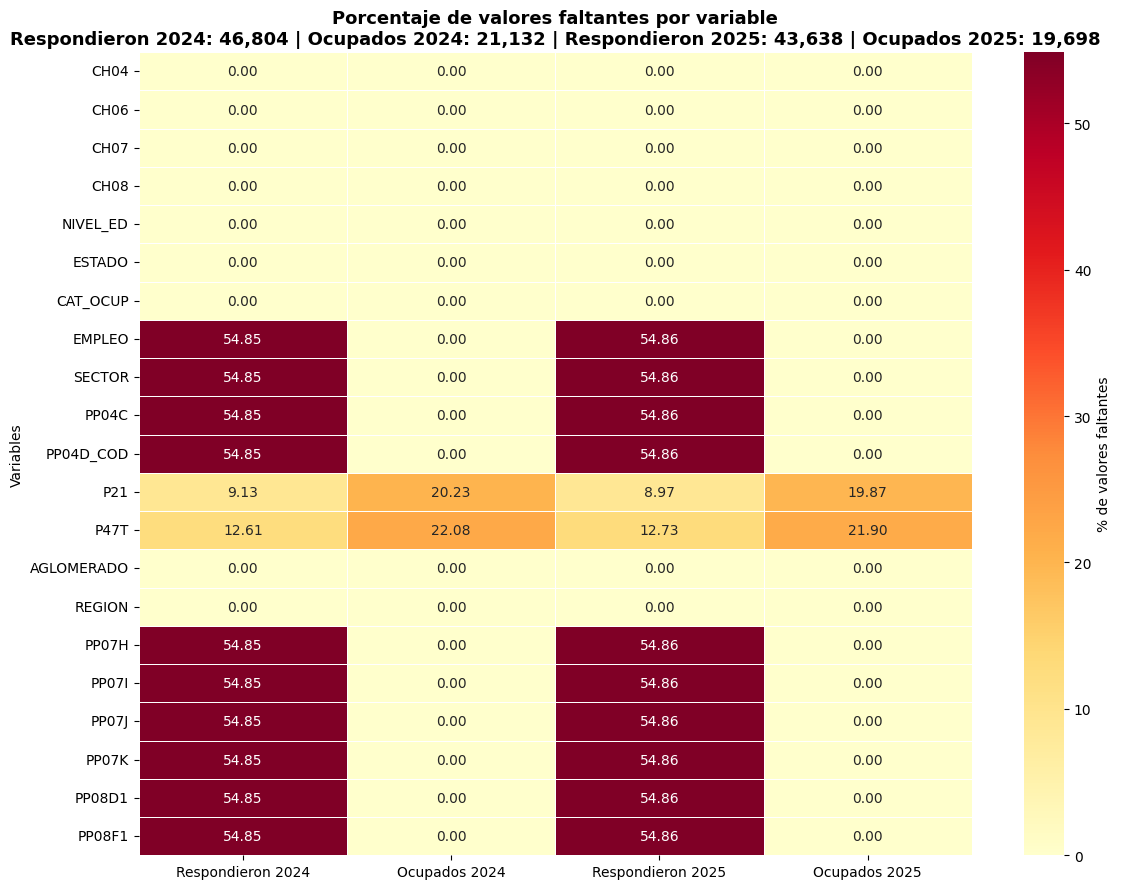

,Respondieron 2024,Ocupados 2024,Respondieron 2025,Ocupados 2025
CH04,0.00,0.00,0.00,0.00
CH06,0.00,0.00,0.00,0.00
CH07,0.00,0.00,0.00,0.00
CH08,0.00,0.00,0.00,0.00
NIVEL_ED,0.00,0.00,0.00,0.00
ESTADO,0.00,0.00,0.00,0.00
CAT_OCUP,0.00,0.00,0.00,0.00
EMPLEO,54.85,0.00,54.86,0.00
SECTOR,54.85,0.00,54.86,0.00
PP04C,54.85,0.00,54.86,0.00


In [18]:
# Respondieron vs ocupados, 2024 y 2025
variables_faltantes = variables_obligatorias + variables_adicionales

faltantes = pd.DataFrame({
    "Respondieron 2024": respondieron[respondieron["anio"] == 2024][variables_faltantes].isna().mean() * 100,
    "Ocupados 2024": ocupados[ocupados["anio"] == 2024][variables_faltantes].isna().mean() * 100,
    "Respondieron 2025": respondieron[respondieron["anio"] == 2025][variables_faltantes].isna().mean() * 100,
    "Ocupados 2025": ocupados[ocupados["anio"] == 2025][variables_faltantes].isna().mean() * 100
}).round(2)

n_resp_2024 = len(respondieron[respondieron["anio"] == 2024])
n_ocup_2024 = len(ocupados[ocupados["anio"] == 2024])
n_resp_2025 = len(respondieron[respondieron["anio"] == 2025])
n_ocup_2025 = len(ocupados[ocupados["anio"] == 2025])

plt.figure(figsize=(12, 9))

sns.heatmap(
    faltantes,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "% de valores faltantes"}
)

plt.title(
    "Porcentaje de valores faltantes por variable\n"
    f"Respondieron 2024: {n_resp_2024:,} | Ocupados 2024: {n_ocup_2024:,} | "
    f"Respondieron 2025: {n_resp_2025:,} | Ocupados 2025: {n_ocup_2025:,}",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Variables")
plt.tight_layout()

plt.savefig("salidas/Figura_Heatmap_Valores_Faltantes.png", dpi=300, bbox_inches="tight")
plt.show()

faltantes

# 13. Matriz de correlación 2024

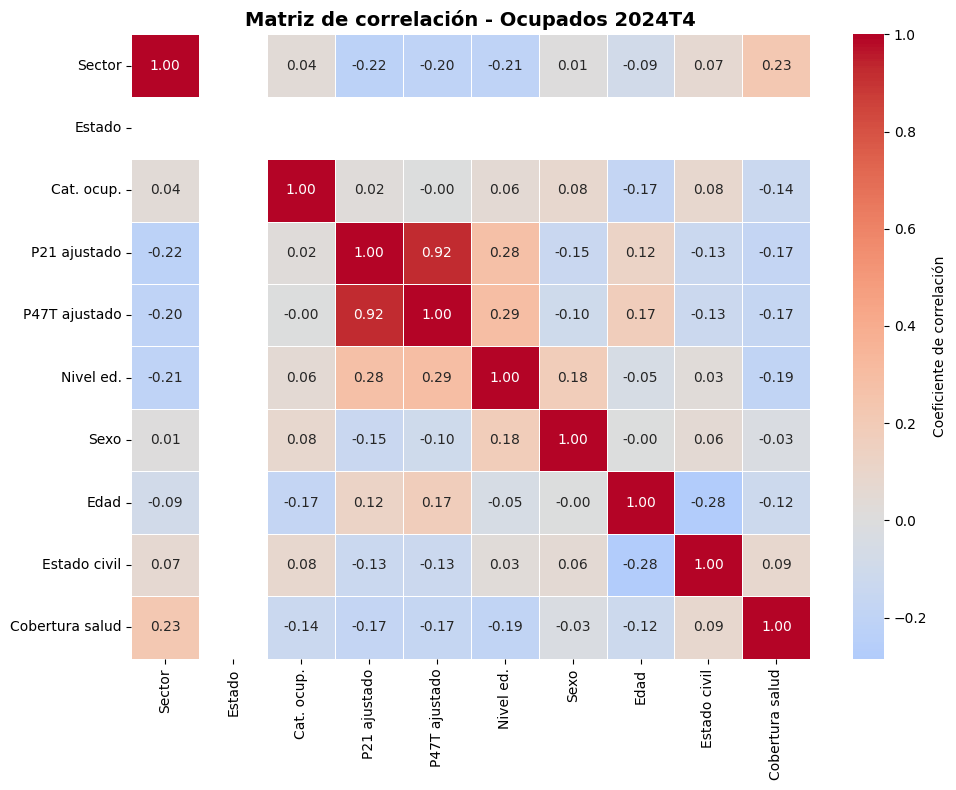

,Sector,Estado,Cat. ocup.,P21 ajustado,P47T ajustado,Nivel ed.,Sexo,Edad,Estado civil,Cobertura salud
Sector,1.00,NaN,0.04,-0.22,-0.20,-0.21,0.01,-0.09,0.07,0.23
Estado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cat. ocup.,0.04,NaN,1.00,0.02,-0.00,0.06,0.08,-0.17,0.08,-0.14
P21 ajustado,-0.22,NaN,0.02,1.00,0.92,0.28,-0.15,0.12,-0.13,-0.17
P47T ajustado,-0.20,NaN,-0.00,0.92,1.00,0.29,-0.10,0.17,-0.13,-0.17
Nivel ed.,-0.21,NaN,0.06,0.28,0.29,1.00,0.18,-0.05,0.03,-0.19
Sexo,0.01,NaN,0.08,-0.15,-0.10,0.18,1.00,-0.00,0.06,-0.03
Edad,-0.09,NaN,-0.17,0.12,0.17,-0.05,-0.00,1.00,-0.28,-0.12
Estado civil,0.07,NaN,0.08,-0.13,-0.13,0.03,0.06,-0.28,1.00,0.09
Cobertura salud,0.23,NaN,-0.14,-0.17,-0.17,-0.19,-0.03,-0.12,0.09,1.00


In [19]:

vars_corr = [
    "SECTOR",
    "ESTADO",
    "CAT_OCUP",
    "P21_ajustado",
    "P47T_ajustado",
    "NIVEL_ED",
    "CH04",
    "CH06",
    "CH07",
    "CH08"
]

nombres_corr = {
    "SECTOR": "Sector",
    "ESTADO": "Estado",
    "CAT_OCUP": "Cat. ocup.",
    "P21_ajustado": "P21 ajustado",
    "P47T_ajustado": "P47T ajustado",
    "NIVEL_ED": "Nivel ed.",
    "CH04": "Sexo",
    "CH06": "Edad",
    "CH07": "Estado civil",
    "CH08": "Cobertura salud"
}

corr_2024 = (
    ocupados[ocupados["anio"] == 2024][vars_corr]
    .corr()
    .rename(index=nombres_corr, columns=nombres_corr)
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_2024,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Coeficiente de correlación"}
)

plt.title("Matriz de correlación - Ocupados 2024T4", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig("salidas/Figura_Matriz_Correlacion_2024.png", dpi=300, bbox_inches="tight")
plt.show()

corr_2024

#14. Matriz de correlación 2025

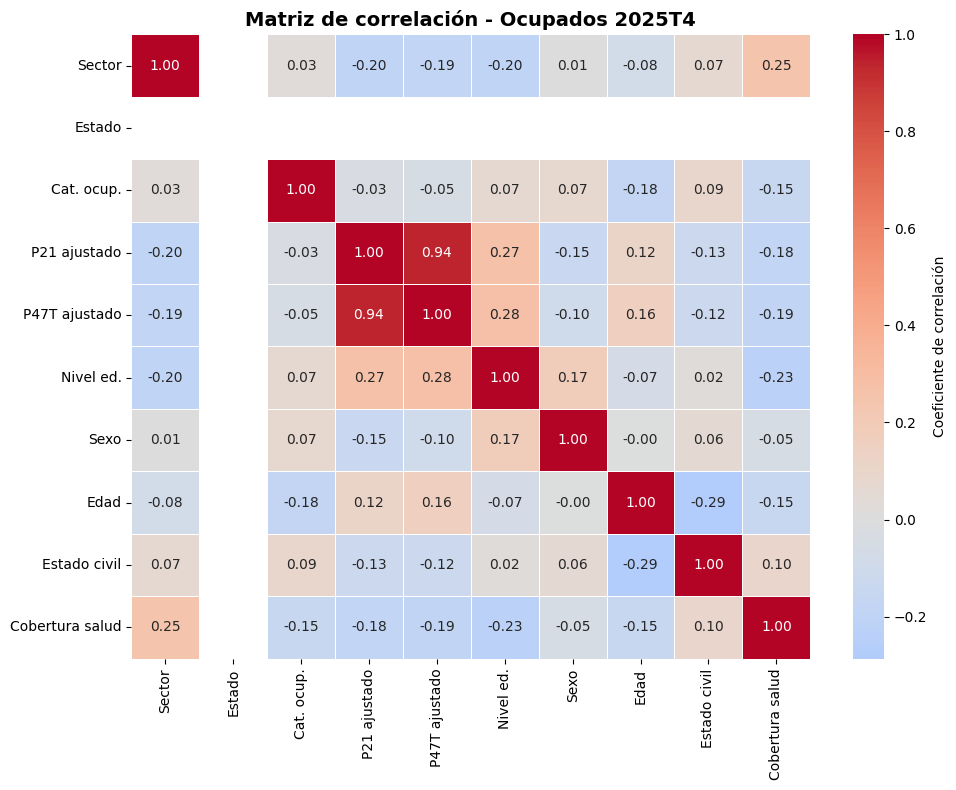

,Sector,Estado,Cat. ocup.,P21 ajustado,P47T ajustado,Nivel ed.,Sexo,Edad,Estado civil,Cobertura salud
Sector,1.00,NaN,0.03,-0.20,-0.19,-0.20,0.01,-0.08,0.07,0.25
Estado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cat. ocup.,0.03,NaN,1.00,-0.03,-0.05,0.07,0.07,-0.18,0.09,-0.15
P21 ajustado,-0.20,NaN,-0.03,1.00,0.94,0.27,-0.15,0.12,-0.13,-0.18
P47T ajustado,-0.19,NaN,-0.05,0.94,1.00,0.28,-0.10,0.16,-0.12,-0.19
Nivel ed.,-0.20,NaN,0.07,0.27,0.28,1.00,0.17,-0.07,0.02,-0.23
Sexo,0.01,NaN,0.07,-0.15,-0.10,0.17,1.00,-0.00,0.06,-0.05
Edad,-0.08,NaN,-0.18,0.12,0.16,-0.07,-0.00,1.00,-0.29,-0.15
Estado civil,0.07,NaN,0.09,-0.13,-0.12,0.02,0.06,-0.29,1.00,0.10
Cobertura salud,0.25,NaN,-0.15,-0.18,-0.19,-0.23,-0.05,-0.15,0.10,1.00


In [20]:

corr_2025 = (
    ocupados[ocupados["anio"] == 2025][vars_corr]
    .corr()
    .rename(index=nombres_corr, columns=nombres_corr)
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_2025,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Coeficiente de correlación"}
)

plt.title("Matriz de correlación - Ocupados 2025T4", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig("salidas/Figura_Matriz_Correlacion_2025.png", dpi=300, bbox_inches="tight")
plt.show()

corr_2025

#15. Estadística descriptiva

In [21]:
variables_descriptivas = [
    "CH04", "CH06", "CH07", "CH08", "NIVEL_ED",
    "ESTADO", "CAT_OCUP", "EMPLEO", "SECTOR",
    "PP04C", "PP04D_COD",
    "P21_ajustado", "P47T_ajustado",
    "mujer", "casado_unido", "universitario", "asalariado",
    "formal_wage_employee",
    "upper_tier_informal_wage_employee"
]

def tabla_descriptiva(df, variables):
    tabla = df[variables].describe(
        percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
    ).T

    tabla = tabla.rename(columns={
        "count": "n",
        "mean": "promedio",
        "std": "desvio_estandar",
        "min": "min",
        "1%": "p1",
        "25%": "p25",
        "50%": "p50",
        "75%": "p75",
        "99%": "p99",
        "max": "max"
    })

    return tabla.round(2)

tabla_desc_2024 = tabla_descriptiva(
    ocupados[ocupados["anio"] == 2024],
    variables_descriptivas
)

tabla_desc_2025 = tabla_descriptiva(
    ocupados[ocupados["anio"] == 2025],
    variables_descriptivas
)

print("Descriptivos 2024")
display(tabla_desc_2024)

print("Descriptivos 2025")
display(tabla_desc_2025)

Descriptivos 2024


,n,promedio,desvio_estandar,min,p1,p25,p50,p75,p99,max
CH04,"21,132.00",1.45,0.50,1.00,1.00,1.00,1.00,2.00,2.00,2.00
CH06,"21,132.00",41.31,13.13,11.00,19.00,31.00,40.00,51.00,73.00,92.00
CH07,"21,132.00",2.92,1.69,1.00,1.00,1.00,2.00,5.00,5.00,5.00
CH08,"21,132.00",2.10,1.98,1.00,1.00,1.00,1.00,4.00,12.00,123.00
NIVEL_ED,"21,132.00",4.19,1.38,1.00,1.00,3.00,4.00,5.00,6.00,7.00
ESTADO,"21,132.00",1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
CAT_OCUP,"21,132.00",2.70,0.54,1.00,1.00,2.00,3.00,3.00,3.00,4.00
EMPLEO,"21,132.00",1.44,0.54,1.00,1.00,1.00,1.00,2.00,2.00,9.00
SECTOR,"21,132.00",1.69,1.62,1.00,1.00,1.00,1.00,2.00,9.00,9.00
PP04C,"21,132.00",17.05,31.63,0.00,0.00,1.00,6.00,10.00,99.00,99.00


Descriptivos 2025


,n,promedio,desvio_estandar,min,p1,p25,p50,p75,p99,max
CH04,"19,698.00",1.45,0.50,1.00,1.00,1.00,1.00,2.00,2.00,2.00
CH06,"19,698.00",41.86,13.29,12.00,19.00,31.00,41.00,52.00,73.00,100.00
CH07,"19,698.00",2.91,1.68,1.00,1.00,1.00,2.00,5.00,5.00,9.00
CH08,"19,698.00",2.11,1.75,1.00,1.00,1.00,1.00,4.00,12.00,23.00
NIVEL_ED,"19,698.00",4.17,1.38,1.00,1.00,3.00,4.00,5.00,6.00,7.00
ESTADO,"19,698.00",1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
CAT_OCUP,"19,698.00",2.68,0.55,1.00,1.00,2.00,3.00,3.00,3.00,4.00
EMPLEO,"19,698.00",1.45,0.53,1.00,1.00,1.00,1.00,2.00,2.00,9.00
SECTOR,"19,698.00",1.68,1.58,1.00,1.00,1.00,1.00,2.00,9.00,9.00
PP04C,"19,698.00",17.69,32.56,0.00,0.00,1.00,6.00,10.00,99.00,99.00


#16. Gráfico de ingresos 2024

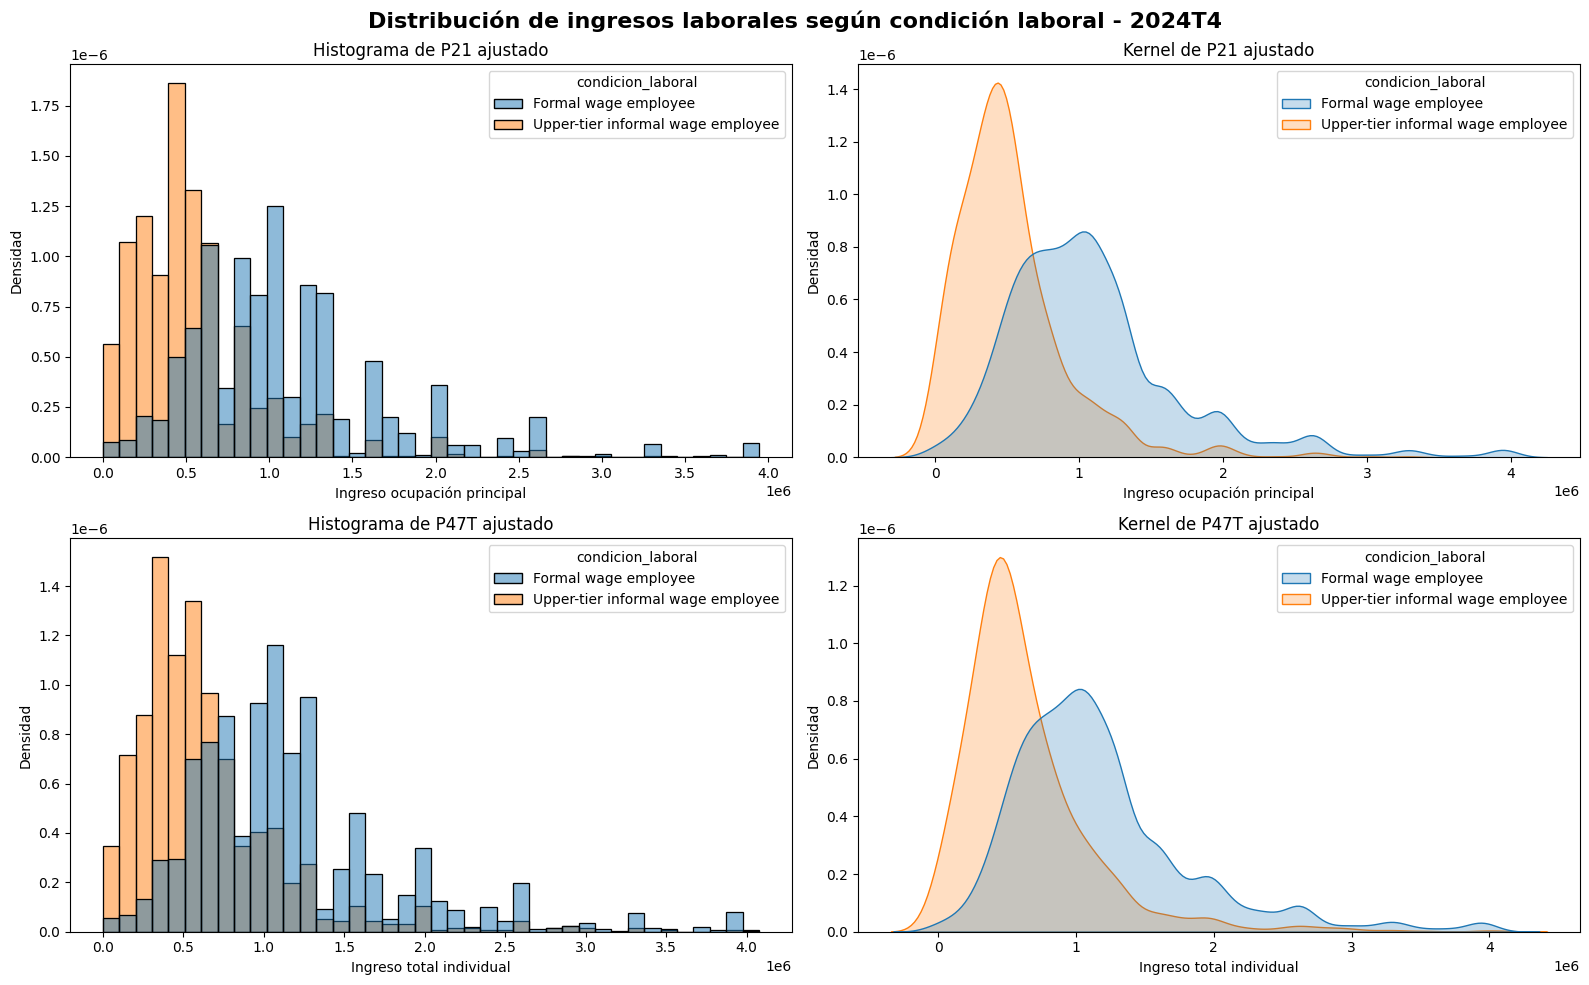

In [22]:
def preparar_base_grafico(df, anio):
    sub = df[
        (df["anio"] == anio) &
        (df["P21_ajustado"].notna()) &
        (df["P47T_ajustado"].notna()) &
        (df["P21_ajustado"] >= 0) &
        (df["P47T_ajustado"] >= 0)
    ].copy()

    # Recorte al percentil 99 para evitar que valores extremos dominen el gráfico
    p99_p21 = sub["P21_ajustado"].quantile(0.99)
    p99_p47t = sub["P47T_ajustado"].quantile(0.99)

    sub = sub[
        (sub["P21_ajustado"] <= p99_p21) &
        (sub["P47T_ajustado"] <= p99_p47t)
    ].copy()

    # Nos quedamos con formales y upper-tier informales para comparación visual
    sub = sub[
        sub["condicion_laboral"].isin([
            "Formal wage employee",
            "Upper-tier informal wage employee"
        ])
    ].copy()

    return sub

ocupados_2024_graf = preparar_base_grafico(ocupados, 2024)

fig, ax = plt.subplots(2, 2, figsize=(16, 10))

fig.suptitle(
    "Distribución de ingresos laborales según condición laboral - 2024T4",
    fontsize=16,
    fontweight="bold"
)

sns.histplot(
    data=ocupados_2024_graf,
    x="P21_ajustado",
    hue="condicion_laboral",
    bins=40,
    stat="density",
    common_norm=False,
    ax=ax[0, 0]
)
ax[0, 0].set_title("Histograma de P21 ajustado")
ax[0, 0].set_xlabel("Ingreso ocupación principal")
ax[0, 0].set_ylabel("Densidad")

sns.kdeplot(
    data=ocupados_2024_graf,
    x="P21_ajustado",
    hue="condicion_laboral",
    fill=True,
    common_norm=False,
    ax=ax[0, 1]
)
ax[0, 1].set_title("Kernel de P21 ajustado")
ax[0, 1].set_xlabel("Ingreso ocupación principal")
ax[0, 1].set_ylabel("Densidad")

sns.histplot(
    data=ocupados_2024_graf,
    x="P47T_ajustado",
    hue="condicion_laboral",
    bins=40,
    stat="density",
    common_norm=False,
    ax=ax[1, 0]
)
ax[1, 0].set_title("Histograma de P47T ajustado")
ax[1, 0].set_xlabel("Ingreso total individual")
ax[1, 0].set_ylabel("Densidad")

sns.kdeplot(
    data=ocupados_2024_graf,
    x="P47T_ajustado",
    hue="condicion_laboral",
    fill=True,
    common_norm=False,
    ax=ax[1, 1]
)
ax[1, 1].set_title("Kernel de P47T ajustado")
ax[1, 1].set_xlabel("Ingreso total individual")
ax[1, 1].set_ylabel("Densidad")

plt.tight_layout()

plt.savefig("salidas/Figura_Distribucion_Ingresos_2024.png", dpi=300, bbox_inches="tight")
plt.show()

#17. Tabla comparativa resumen

In [23]:
def media_ponderada(df, variable, peso="PONDERA"):
    sub = df[[variable, peso]].dropna()
    if sub[peso].sum() == 0:
        return np.nan
    return np.average(sub[variable], weights=sub[peso])

filas = []

for anio in [2024, 2025]:
    sub = ocupados[ocupados["anio"] == anio]

    filas.append({
        "Año": anio,
        "Ocupados muestrales": len(sub),
        "Edad promedio": media_ponderada(sub, "CH06"),
        "Mujeres (%)": media_ponderada(sub, "mujer") * 100,
        "Asalariados (%)": media_ponderada(sub, "asalariado") * 100,
        "Formal wage employees (%)": media_ponderada(sub, "formal_wage_employee") * 100,
        "Upper-tier informal wage employees (%)": media_ponderada(sub, "upper_tier_informal_wage_employee") * 100,
        "Ingreso P21 promedio ajustado": media_ponderada(sub, "P21_ajustado"),
        "Ingreso P47T promedio ajustado": media_ponderada(sub, "P47T_ajustado")
    })

tabla_resumen = pd.DataFrame(filas).round(2)
tabla_resumen

,Año,Ocupados muestrales,Edad promedio,Mujeres (%),Asalariados (%),Formal wage employees (%),Upper-tier informal wage employees (%),Ingreso P21 promedio ajustado,Ingreso P47T promedio ajustado
0,2024,21132,41.32,44.66,72.32,46.20,7.25,"904,073.36","1,038,222.87"
1,2025,19698,41.69,44.39,71.53,45.55,6.68,"1,029,848.30","1,160,022.66"


#18. Exportar tablas y figuras

In [28]:
# Carpeta donde se guardarán los resultados
ruta_salidas_drive = ruta + "salidas/"

# Crear carpeta si no existe
os.makedirs(ruta_salidas_drive, exist_ok=True)

print("Los resultados se guardarán en:")
print(ruta_salidas_drive)

# ============================================================
# Exportar tablas directamente a Google Drive
# ============================================================

tabla_informalidad.to_excel(
    ruta_salidas_drive + "Tabla_Informalidad_Grupo2.xlsx",
    index=False
)

tabla_desc_2024.to_excel(
    ruta_salidas_drive + "Tabla_Descriptiva_2024.xlsx"
)

tabla_desc_2025.to_excel(
    ruta_salidas_drive + "Tabla_Descriptiva_2025.xlsx"
)

tabla_resumen.to_excel(
    ruta_salidas_drive + "Tabla_Resumen_Comparativo.xlsx",
    index=False
)

faltantes.to_excel(
    ruta_salidas_drive + "Tabla_Faltantes.xlsx"
)

corr_2024.to_excel(
    ruta_salidas_drive + "Matriz_Correlacion_2024.xlsx"
)

corr_2025.to_excel(
    ruta_salidas_drive + "Matriz_Correlacion_2025.xlsx"
)

print("Tablas guardadas correctamente en Drive.")

Los resultados se guardarán en:
/content/drive/MyDrive/tp1_taller_de_programacion/salidas/
Tablas guardadas correctamente en Drive.


In [26]:
# ============================================================
# Chequeo final del notebook
# ============================================================

print("CHEQUEO FINAL")
print("Base completa:", base.shape)
print("Respondieron:", respondieron.shape)
print("No respondieron:", norespondieron.shape)
print("Ocupados:", ocupados.shape)
print()
print("Años en base:", base["anio"].unique())
print()
print("Variables seleccionadas:", len(variables))
print(variables)
print()
print("Distribución de condición laboral:")
display(ocupados.groupby(["anio", "condicion_laboral"]).size().reset_index(name="n"))
print()
print("Archivos en carpeta salidas:")
print(os.listdir("salidas"))

CHEQUEO FINAL
Base completa: (90563, 28)
Respondieron: (90442, 30)
No respondieron: (121, 28)
Ocupados: (40830, 44)

Años en base: [2024 2025]

Variables seleccionadas: 27
['CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'COMPONENTE', 'PONDERA', 'CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_OCUP', 'EMPLEO', 'SECTOR', 'PP04C', 'PP04D_COD', 'P21', 'P47T', 'AGLOMERADO', 'REGION', 'PP07H', 'PP07I', 'PP07J', 'PP07K', 'PP08D1', 'PP08F1']

Distribución de condición laboral:


,anio,condicion_laboral,n
0,2024,Formal wage employee,9727
1,2024,Lower-tier informal wage employee,2004
2,2024,Resto de ocupados,7823
3,2024,Upper-tier informal wage employee,1578
4,2025,Formal wage employee,8815
5,2025,Lower-tier informal wage employee,1812
6,2025,Resto de ocupados,7694
7,2025,Upper-tier informal wage employee,1377



Archivos en carpeta salidas:
['Figura_Matriz_Correlacion_2025.png', 'Matriz_Correlacion_2025.xlsx', 'Figura_Distribucion_Ingresos_2024.png', 'Matriz_Correlacion_2024.xlsx', 'Figura_Matriz_Correlacion_2024.png', 'Tabla_Descriptiva_2025.xlsx', 'Figura_Heatmap_Valores_Faltantes.png', 'Tabla_Faltantes.xlsx', 'Tabla_Descriptiva_2024.xlsx', 'Tabla_Informalidad_Grupo2.xlsx', 'Tabla_Resumen_Comparativo.xlsx']


## Fin del Trabajo Práctico

Todas las tablas, gráficos y resultados presentados en el informe fueron generados mediante este notebook.

Repositorio GitHub:
https://github.com/PabloTallerProgramacion/TP1_Programacion_UBA.git